In [ ]:
from google.colab import files

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")


Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


In [ ]:
print(path)

/kaggle/input/plantvillage-dataset


In [ ]:
import os

os.listdir(path)

['plantvillage dataset']

In [ ]:
from pathlib import Path
dataset = Path(path)

In [ ]:
classes = [d.name for d in dataset.iterdir() if d.is_dir()]
print("Number of classes:", len(classes))
print(classes[:10])

Number of classes: 1
['plantvillage dataset']


In [ ]:
for item in dataset.iterdir():
    print(item)

/kaggle/input/plantvillage-dataset/plantvillage dataset


In [ ]:
root = dataset / "plantvillage dataset"
for item in root.iterdir():
    print(item)

/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented
/kaggle/input/plantvillage-dataset/plantvillage dataset/grayscale
/kaggle/input/plantvillage-dataset/plantvillage dataset/color


In [ ]:
color_path = root / "color"
print(len(list(color_path.iterdir())))

38


In [ ]:
color_path = root / "segmented"
print(len(list(color_path.iterdir())))

38


In [ ]:
color_path = root / "grayscale"
print(len(list(color_path.iterdir())))

38


In [ ]:
classes = sorted([d.name for d in color_path.iterdir() if d.is_dir()])

print("Total classes:", len(classes))
print(classes)

Total classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', '

In [ ]:
import pandas as pd

In [ ]:
class_path = dataset / "plantvillage dataset" / "color" / classes[0]
print(len(list(class_path.glob("*"))))

630


In [ ]:
class_counts = {}
for cls in classes:
    class_path = dataset / "plantvillage dataset" / "color" / cls
    class_counts[cls] = len(list(class_path.glob("*")))
df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Images"]
).sort_values("Images", ascending=True)
df

,Class,Images
22,Potato___healthy,152
2,Apple___Cedar_apple_rust,275
17,Peach___healthy,360
23,Raspberry___healthy,371
36,Tomato___Tomato_mosaic_virus,373
14,Grape___healthy,423
27,Strawberry___healthy,456
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
1,Apple___Black_rot,621
0,Apple___Apple_scab,630


In [ ]:
import matplotlib.pyplot as plt

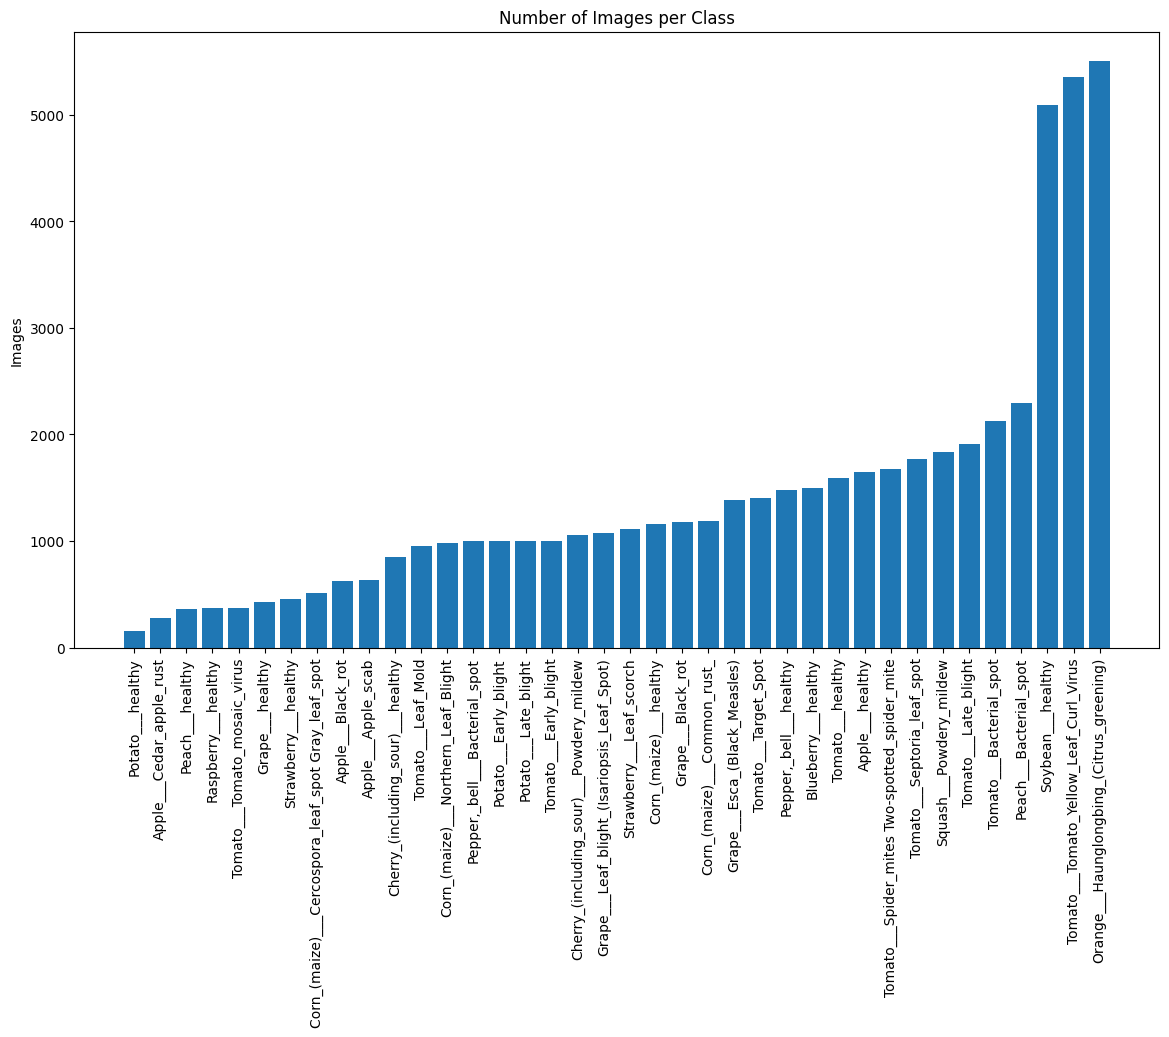

In [ ]:
plt.figure(figsize=(14,8))
plt.bar(df["Class"], df["Images"])
plt.xticks(rotation=90)
plt.ylabel("Images")
plt.title("Number of Images per Class")
plt.show()

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
root = Path("/kaggle/input/plantvillage-dataset/plantvillage dataset/color")

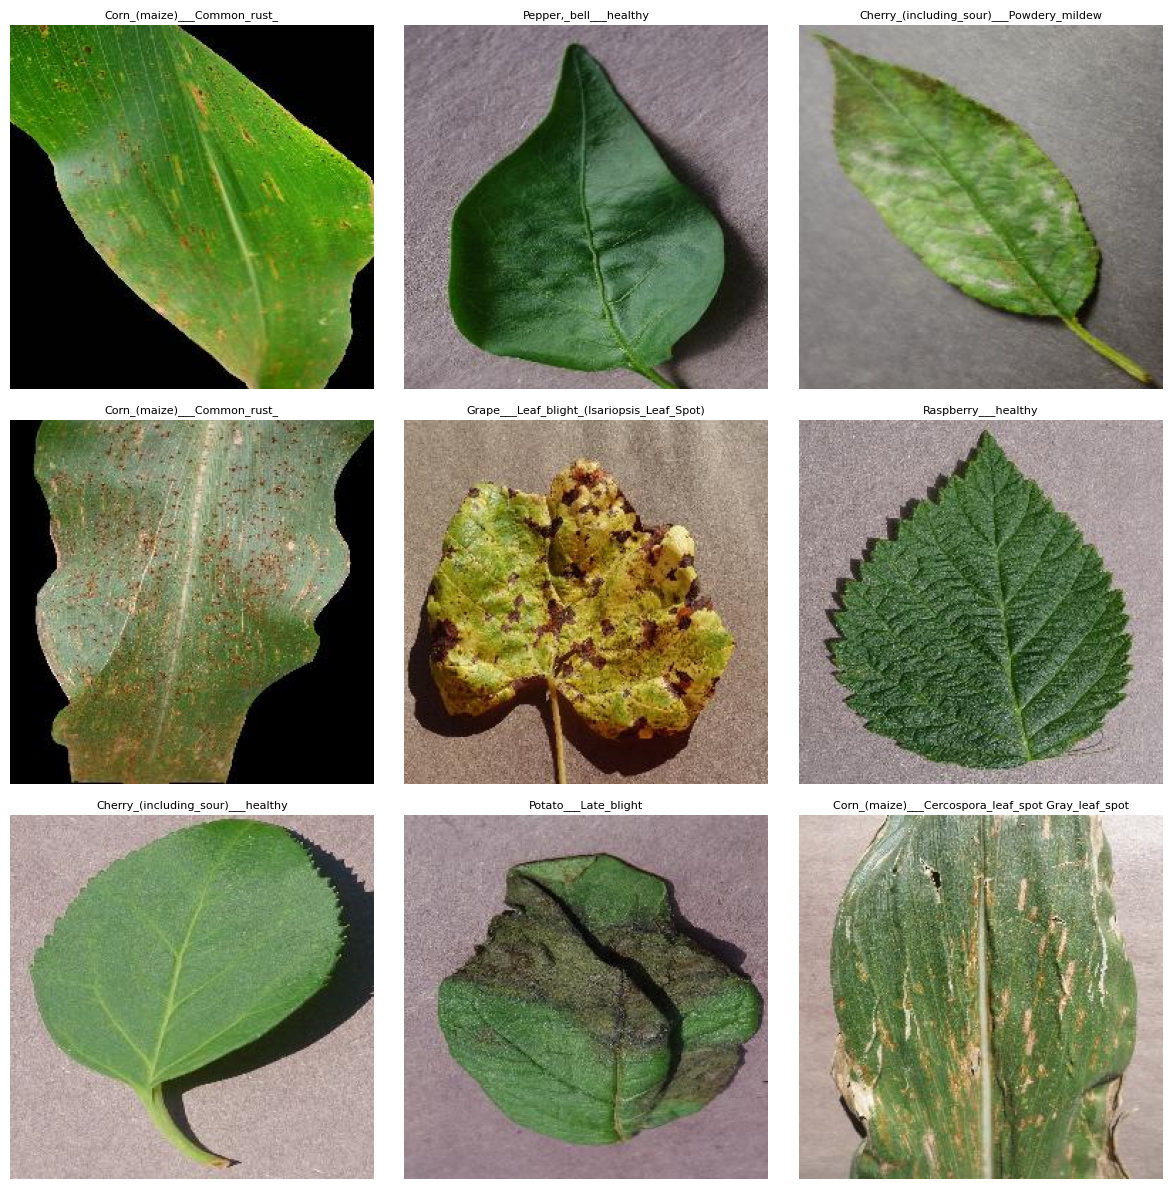

In [ ]:
fig, axes = plt.subplots(3,3, figsize=(12,12))

for ax in axes.flatten():
    cls = random.choice(classes)
    img_path = random.choice(list(( dataset / "plantvillage dataset" / "color" / cls).glob("*")))

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")

plt.tight_layout()

In [ ]:
sizes = []

for cls in classes:
    images = list((class_path).glob("*"))

    for img_path in random.sample(images, min(20, len(images))):
        img = Image.open(img_path)
        sizes.append(img.size)

sizes[:10]

[(256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256)]

In [ ]:
corrupted = []

for cls in classes:
    for img_path in (class_path).glob("*"):
        try:
            Image.open(img_path).verify()
        except:
            corrupted.append(img_path)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


Sample class: Grape___Black_rot
Images found: 1180


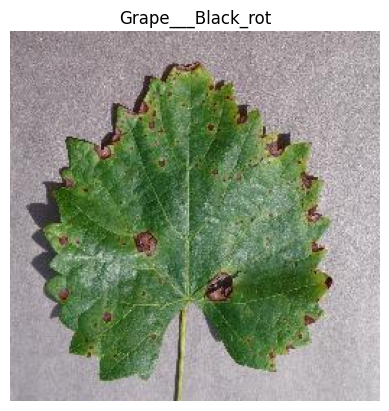

In [ ]:
sample_class = random.choice(classes)
print("Sample class:", sample_class)
img_paths = list((root / sample_class).rglob("*"))
img_paths = [
    p for p in img_paths
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
]
print("Images found:", len(img_paths))
img_path = random.choice(img_paths)

img = Image.open(img_path)

plt.imshow(img)
plt.title(sample_class)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

In [ ]:
means = []
stds = []
sample_paths = []
for cls in classes:
    sample_paths.extend(list((root / cls).glob("*")))

sample_paths = random.sample(sample_paths, min(200, len(sample_paths)))

for img_path in sample_paths:
    img = Image.open(img_path).convert("RGB")
    img = np.array(img) / 255.0

    means.append(img.mean(axis=(0, 1)))
    stds.append(img.std(axis=(0, 1)))

mean = np.mean(means, axis=0)
std = np.mean(stds, axis=0)

print("RGB Mean :", mean)
print("RGB Std  :", std)

RGB Mean : [0.46328481 0.4885463  0.41154077]
RGB Std  : [0.17564758 0.1489075  0.19117981]


In [ ]:
import hashlib
from pathlib import Path

hashes = {}
duplicates = []

for img_path in root.rglob("*"):
    if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    with open(img_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    if file_hash in hashes:
        duplicates.append((hashes[file_hash], img_path))
    else:
        hashes[file_hash] = img_path

print("Duplicate images found:", len(duplicates))

Duplicate images found: 21


negligible duplicates so im leaving

In [ ]:
import tensorflow as tf

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    root,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    root,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [ ]:
print("Class Names:")
print(train_ds.class_names)

print("\nNumber of classes:", len(train_ds.class_names))

print("\nTraining batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

Class Names:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomat

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [ ]:
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:
for images, labels in train_ds.take(1):
    print("Min pixel value:", tf.reduce_min(images).numpy())
    print("Max pixel value:", tf.reduce_max(images).numpy())

Min pixel value: 0.0
Max pixel value: 1.0


Loaded the PlantVillage RGB dataset (38 disease/healthy classes).
Verified the dataset structure and class folders.
Checked for corrupted or unreadable images.
Verified image dimensions and formats for consistency.
Visualized random samples from different classes to inspect data quality.
Analyzed class distribution to identify any imbalance.
Computed RGB channel mean and standard deviation for pixel statistics.
Detected duplicate images (21 duplicates found, negligible relative to the dataset size).
Created an 80:20 train-validation split using TensorFlow.